<a href="https://colab.research.google.com/github/Zain506/MedCLIP-SAM/blob/main/notebooks/ImageSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Segmentation

**MedCLIP-SAM**
[Paper](https://arxiv.org/pdf/2403.20253)


**gScoreCAM**
[Paper](https://www.google.com/url?q=https%3A%2F%2Fopenaccess.thecvf.com%2Fcontent%2FACCV2022%2Fpapers%2FChen_gScoreCAM_What_objects_is_CLIP_looking_at_ACCV_2022_paper.pdf)

In [134]:
%pip install open-clip-torch -q

In [135]:
# Import data
from datasets import load_dataset
ds = load_dataset("adishourya/MEDPIX-ClinQA") # Same MedPIX dataset that fine-tuned MedCLIP
train_valid = ds["train"].train_test_split(test_size=0.1)
training = train_valid["train"].select(range(100))
test = train_valid["test"]

In [136]:
print(training)

Dataset({
    features: ['image_id', 'mode', 'case_id', 'question', 'answer'],
    num_rows: 100
})


In [137]:
from google.colab import drive

drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Load BiomedCLIP

In [138]:
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import open_clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
weights_path = "/content/drive/MyDrive/colab/MedCLIP-SAM/biomedclip_weights.pth"
model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k")
state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

dict_keys(['image_id', 'mode', 'case_id', 'question', 'answer'])
What could the diagnosis suggest?
The possible diagnosis includes Cholangiocarcinoma
Hepatocellular carcinoma
Abscess
Metastatic neoplasm.


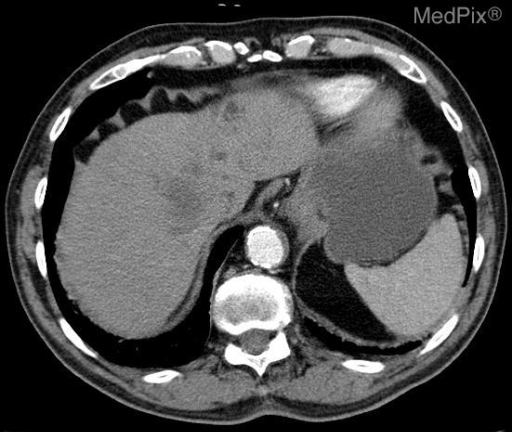

In [139]:
# Obtain attention maps from each head of 1 image
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
print(training[0].keys())
print(training[0]["question"])
print(training[0]["answer"])
image = training[0]["image_id"]
image

In [140]:
model.eval()
model = model.to(device)
img = preprocess(image).unsqueeze(0).to(device)
print(img.shape)

torch.Size([1, 3, 224, 224])


In [141]:
# We are looking for the final attention layer
# We place a hook in it to retrieve
modules = dict(model.named_modules())
print(modules[""]) # Full model. Other sublayers retrieved with keys

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [142]:
features = {}

def get_activation(name):
    def hook(model, input, output):
        # Check if the output is a tuple and get the attention tensor
        print(type(output))
        print(output[0].shape)
    return hook

handle = model.visual.transformer.resblocks[-1].attn.register_forward_hook(get_activation("attn"))

In [143]:
with torch.no_grad():
    _ = model.encode_image(img)

handle.remove()

<class 'tuple'>
torch.Size([1, 50, 768])
